# Biblioteka do automatycznego różniczkowania

Kacper Aleksander 325446

In [2]:
using LinearAlgebra

abstract type Operator end # abstrakcyjny typ Operator
const Chain = Vector{Operator} # alias Chain do Vector{Operator}
abstract type Loss end # abstrakcyjny typ Loss

# Tensor
struct Tensor{N}
  # struktura Tensor z parametrem N, który jest przekazywany do NTuple. Czyli Tensor N
  # składa się z atrybutu outsize, który jest typu NTuple o długości N i każdy z jego
  # elementów ma typ Int64 
  outsize :: NTuple{N, Int64}
end
  tensor(sz...) = Tensor(sz)()
# ... to tzw. splat operator, jak *args w Pythonie. Można wtedy pisać tensor(2, 3, 4), co spowoduje spakowanie
# tych wartości do krotki: sz = (2, 3, 4) i uruchomienie konstruktora Tensor(sz). Krotka sz zostanie przekształcona
# na NTuple{N, Int64} automatycznie, aby dopasować się do definicji atrybutu "outsize" Tensora.

function (x::Tensor{N})() where N
  data = zeros(x.outsize...)
  return GraphNode(data)
end

function chain(operators)
# chain to funkcja tworząca wektor operatorów. Wejściem jest wektor składający się z pojedynczych
# operatorów lub krotek operatorów - w tym drugim przypadku są one odpakowywane
  function flatten(x::Tuple)
    y = Vector{Operator}()
    for v in x
      if v isa Tuple
        push!(y, v...)
      else
        push!(y, v)
      end
      end
    return y
  end

  result = Vector{Operator}()
  for operator in flatten(operators)
    push!(result, operator)
  end
  return result
end

function (chain::Chain)(x)
# (chain::Chain) oznacza, że jest to funkcja nieprzypisana do nazwy, a do każdego z obiektów
# typu Chain. x to argument.
  node = x # wartość początkowa
  for op in chain
    node = op(node) # dla każdej operacji w chainie (wektorze operacji) wykonaj tę operację na wartości node.
  end
  return node # zwróć uzyskaną wartość
end
mutable struct GraphNode{OP, N}
  args :: NTuple{N, GraphNode}
  grad
  data
end

const GraphWeight = GraphNode{:weight, 0} # Węzeł bez argumentów gdzie OP = :weight
const GraphTensor = GraphNode{:tensor, 0} # Węzeł bez argumentów gdzie OP = :tensor

# Konstruktor dla danych jak wagi i tensory (obrazy), czyli nieposiadających argumentów (rodziców):
function GraphNode(data::T, trainable=false) where T
  if trainable # wagi są trainable
    return GraphNode{:weight, 0}((), zero(data), data)
  else # tensory nie są trainable
    return GraphNode{:tensor, 0}((), zero(data), data)
  end
end

# Konstruktor dla operatorów-symboli, czyli operatorów, które zaczynają się od :, np. :mul.
# Wymaga podania argumentów! (args)
function GraphNode(op::Symbol, args::Tuple, data::T) where T
  N = length(args)
  grad = similar(data)
  return GraphNode{op, N}(args, grad, data)
end

# Zwracanie wektora GraphNode'ów w kolejności:
function graph(node)
  function visit!(node::GraphNode, visited, ordered)
    if node in visited
    else # jeśli node nie był odwiedzony
      push!(visited, node) # dodaj node do odwiedzonych
      for arg in node.args # dla każdego argumentu w node (jeżeli są)
        visit!(arg, visited, ordered)
        # Odwiedź argumenty ZANIM dodasz obecny node do listy.
        # Gwarantuje to odpowiednią kolejność w grafie. 
      end
      push!(ordered, node)
    end
    return nothing
  end
  ordered = Vector{GraphNode}() # utwórz wektor gdzie każdy element to GraphNode
  visited = Set{GraphNode}() # utwórz wektor z odwiedzonymi GraphNode'ami
  visit!(node, visited, ordered) # odwiedź node i modyfikuj visited oraz ordered
  return ordered # zwróć uporządkowany wektor GraphNode'ów
end

# Funkcja do wyzerowywania gradientu w całym wektorze GraphNode'ów:
function zerograd!(order :: Vector{GraphNode})
  for node in order
    node.grad .= 0
  end
end

# Funkcje, które nic nie robią, ale zapobiegają błędowi kompilatora.
# primal! liczy wartość przejścia w przód - ale nie trzeba jej liczyć dla GraphTensor
# i GraphWeight, ponieważ te wartości są ustalone.
# adjoint! liczy gradient.
function primal!(tensor::GraphTensor) end
function primal!(weight::GraphWeight) end
function adjoint!(::GraphTensor) end
function adjoint!(::GraphWeight) end

# Funkcja forward! przyjmuje posortowany wektor GraphNode'ów oraz pary
# i inicjalizuje data w GraphNode'ach faktycznymi wartościami, a następnie
# przechodzi po Vector{GraphNode} i liczy wartości za pomocą funkcji określonych
# w sekcji Operatory.
function forward!(order::Vector{GraphNode}, pairs...)
  for pair in pairs
    tensor,data = pair
    tensor.data .= data
  end

  for node in order
    primal!(node)
  end
end

# Funkcja backward! liczy gradient.
function backward!(order::Vector{GraphNode})
	seed = last(order)
	seed.grad .= 1

  for node in reverse(order) # w przeciwnym kierunku niż forward!
    adjoint!(node)
  end
end

# Algorytm spadku gradientu
function optimize!(graph, η)
  for node in graph
	if node isa GraphWeight
      node.data .-= η * node.grad
    end
  end
end

# Wyświetlanie
import Base: show
show(io::IO, x::GraphNode{OP, N}) where {OP,N} =
  print(io, "layer ", OP, " with ", N, " arg(s)")
show(io::IO, x::GraphWeight) = print(io, "weight")
show(io::IO, x::GraphTensor) = print(io, "tensor")

show (generic function with 274 methods)

## Operatory

In [3]:
# Add

function primal!(z::GraphNode{:add, 2})
  x, y = z.args
  z.data .= x.data .+ y.data
  return nothing
end

function adjoint!(z::GraphNode{:add, 2})
  x, y = z.args
  
  # If x is a matrix (batch) and y is a vector (bias), sum across the batch dimension (dims=2)
  if length(size(x.data)) == 2 && length(size(y.data)) == 1
      x.grad .+= z.grad
      y.grad .+= vec(sum(z.grad, dims=2)) # vec() forces it back to a 1D vector
  else
      x.grad .+= z.grad
      y.grad .+= z.grad
  end
  return nothing
end

# Sum

function primal!(y::GraphNode{:sum, 1})
  x, = y.args
  y.data = sum(x.data)
  return nothing
end

function adjoint!(y::GraphNode{:sum, 1})
  x, = y.args
  x.grad += y.grad
  return nothing
end

# Mul

function primal!(y::GraphNode{:mul, 2})
  W, x = y.args
  y.data = W.data * x.data
  return nothing
end

function adjoint!(y::GraphNode{:mul, 2})
  W, x = y.args
  W.grad += y.grad * x.data'
  x.grad += W.data' * y.grad
  return nothing
end

# Dot

function primal!(z::GraphNode{:dot, 2})
  x, y = z.args
  z.data = dot(x.data, y.data)
  return nothing
end

function adjoint!(z::GraphNode{:dot, 2})
  x, y = z.args
  x.grad += y.data .* z.grad
  y.grad += x.data .* z.grad
  return nothing
end

# Dense

struct Dense <: Operator # Dense jest jednym z Operatorów
  insize  :: Int64
  outsize :: Int64
end

dense(pair :: Pair{Int64, Int64}) =
  Dense(first(pair), last(pair)) # umożliwia tworzenie warstwy Dense za pomocą pary: np. dense(2 => 16) wykonuje Dense(2, 16)
dense(pair :: Pair{Int64, Int64}, activation) =
  tuple(dense(pair), activation()) # umożliwia tworzenie warstwy wraz z funkcją aktywacji, np. dense(2 => 16, relu)

function (y::Dense)(x)
  n   = y.insize
  m   = y.outsize
  B   = size(x.data, 2) # Get batch size B from the flattened input
  
  W   = GraphNode(randn(m, n) .* 0.01, true) 
  b   = GraphNode(randn(m) .* 0.01, true) 
  
  # Initialize the intermediate nodes with the batch size B!
  mul = GraphNode(:mul, (W, x), zeros(m, B))
  add = GraphNode(:add, (mul, b), zeros(m, B))
  return add
end

# Sigmoid

struct Sigmoid <: Operator end 
sigmoid() = Sigmoid() 

function (y::Sigmoid)(x)
  return GraphNode(:sigmoid, (x,), zeros(size(x.data)))
end

function primal!(y::GraphNode{:sigmoid, 1})
  x, = y.args
  y.data .= 1 ./ (1 .+ exp.(-x.data))
  return nothing
end

function adjoint!(y::GraphNode{:sigmoid, 1})
  x, = y.args
  x.grad .+= exp.(-x.data) ./ (1 .+ exp.(-x.data)) .^ 2 .* y.grad
  return nothing
end

# ReLU

struct ReLU <: Operator end 
relu() = ReLU() 

function (y::ReLU)(x)
  # FIXED: Use size instead of length
  return GraphNode(:relu, (x,), zeros(size(x.data)))
end

function primal!(y::GraphNode{:relu, 1})
  x, = y.args
  y.data .= max.(0, x.data)
  return nothing
end

function adjoint!(y::GraphNode{:relu, 1})
  x, = y.args
  x.grad .+= (x.data .> 0) .* y.grad
  return nothing
end

# BinaryCrossEntropy (BCE)

struct BinaryCrossEntropy <: Loss end # BinaryCrossEntropy należy do Loss
bce(output, target) = BinaryCrossEntropy()(output, target) # skrócenie zapisu

function (E::BinaryCrossEntropy)(x, y)
  return GraphNode(:bce, (x, y), zeros(1))
end

function primal!(z::GraphNode{:bce, 2})
  x, y = z.args
  z.data = -(y.data .* log.(x.data) + (1 .- y.data) .* log.(1 .- x.data))
  return nothing
end

function adjoint!(z::GraphNode{:bce, 2})
  x, y = z.args
  x.grad -= y.data ./ x.data .* z.grad
  x.grad += (1 .- y.data) ./ (1 .- x.data) .* z.grad
  return nothing
end

# --------------------------Nowe--------------------------
# Flatten

struct Flatten <: Operator end
flatten() = Flatten()

function (y::Flatten)(x)
  features = prod(size(x.data)[1:end-1])
  B = size(x.data)[end]
  return GraphNode(:flatten, (x,), zeros(features, B))
end

function primal!(y::GraphNode{:flatten, 1})
  x, = y.args
  B = size(x.data)[end]
  y.data .= reshape(x.data, :, B)
  return nothing
end

function adjoint!(y::GraphNode{:flatten, 1})
  x, = y.args
  x.grad .+= reshape(y.grad, size(x.grad))
  return nothing
end

# Conv

struct Conv <: Operator
  filter_size :: NTuple{2, Int64}
  in_channels :: Int64
  out_channels :: Int64
  pad :: Int64
end

function conv(filter_size::NTuple{2, Int64}, channels::Pair{Int64, Int64}; pad=0, bias=false)
  return Conv(filter_size, first(channels), last(channels), pad)
end

function (y::Conv)(x)
  W_in, H_in, _, B = size(x.data) 
  W_out = W_in + 2*y.pad - y.filter_size[1] + 1
  H_out = H_in + 2*y.pad - y.filter_size[2] + 1
  
  W_shape = (y.filter_size[1], y.filter_size[2], y.in_channels, y.out_channels)
  W = GraphNode(randn(Float32, W_shape) .* 0.1, true) 
  
  return GraphNode(:conv, (W, x), zeros(Float32, W_out, H_out, y.out_channels, B))
end

function primal!(y::GraphNode{:conv, 2})
  W, x = y.args
  # Pass data into a function barrier to lock in the types
  _primal_conv!(y.data, W.data, x.data)
  return nothing
end

function _primal_conv!(y_data::AbstractArray{T1, 4}, W_data::AbstractArray{T2, 4}, x_data::AbstractArray{T3, 4}) where {T1, T2, T3}
  F_w, F_h, C_in, C_out = size(W_data)
  W_in, H_in, _, B = size(x_data)
  W_out, H_out, _, _ = size(y_data)

  y_data .= 0 

  pad_w = (W_out - W_in + F_w - 1) ÷ 2
  pad_h = (H_out - H_in + F_h - 1) ÷ 2

  @inbounds for b in 1:B
    for c_out in 1:C_out
      for c_in in 1:C_in
        for j in 1:H_out
          for i in 1:W_out
             sum_val = zero(T1)
             for dj in 1:F_h
                for di in 1:F_w
                    xi = i + di - 1 - pad_w
                    xj = j + dj - 1 - pad_h
                    # Calculate padding mathematically instead of allocating arrays
                    if 1 <= xi <= W_in && 1 <= xj <= H_in
                        sum_val += x_data[xi, xj, c_in, b] * W_data[di, dj, c_in, c_out]
                    end
                end
             end
             y_data[i, j, c_out, b] += sum_val
          end
        end
      end
    end
  end
end

function adjoint!(y::GraphNode{:conv, 2})
  W, x = y.args
  _adjoint_conv!(y.grad, W.grad, W.data, x.grad, x.data)
  return nothing
end

function _adjoint_conv!(y_grad::AbstractArray{T1, 4}, W_grad::AbstractArray{T2, 4}, W_data::AbstractArray{T2, 4}, x_grad::AbstractArray{T3, 4}, x_data::AbstractArray{T3, 4}) where {T1, T2, T3}
  F_w, F_h, C_in, C_out = size(W_data)
  W_in, H_in, _, B = size(x_data)
  W_out, H_out, _, _ = size(y_grad)

  pad_w = (W_out - W_in + F_w - 1) ÷ 2
  pad_h = (H_out - H_in + F_h - 1) ÷ 2

  @inbounds for b in 1:B
    for c_out in 1:C_out
      for c_in in 1:C_in
        for j in 1:H_out
          for i in 1:W_out
             dy = y_grad[i, j, c_out, b]
             if dy != zero(T1)
                 for dj in 1:F_h
                    for di in 1:F_w
                        xi = i + di - 1 - pad_w
                        xj = j + dj - 1 - pad_h
                        if 1 <= xi <= W_in && 1 <= xj <= H_in
                            W_grad[di, dj, c_in, c_out] += x_data[xi, xj, c_in, b] * dy
                            x_grad[xi, xj, c_in, b] += W_data[di, dj, c_in, c_out] * dy
                        end
                    end
                 end
             end
          end
        end
      end
    end
  end
end

# MaxPool

struct MaxPool <: Operator
  window_size :: NTuple{2, Int64}
end

maxpool(window_size::NTuple{2, Int64}) = MaxPool(window_size)

function (m::MaxPool)(x)
  W_in, H_in, C, B = size(x.data)
  W_out = W_in ÷ m.window_size[1]
  H_out = H_in ÷ m.window_size[2]
  
  return GraphNode(:maxpool, (x,), zeros(Float32, W_out, H_out, C, B))
end

function primal!(y::GraphNode{:maxpool, 1})
  x, = y.args
  _primal_maxpool!(y.data, x.data)
  return nothing
end

function _primal_maxpool!(y_data::AbstractArray{T1, 4}, x_data::AbstractArray{T2, 4}) where {T1, T2}
  W_out, H_out, C, B = size(y_data)
  w_w = size(x_data, 1) ÷ W_out
  w_h = size(x_data, 2) ÷ H_out

  @inbounds for b in 1:B
    for c in 1:C
      for j in 1:H_out
        for i in 1:W_out
          max_val = typemin(T2) # Safely handles Float32 or Float64
          for dj in 1:w_h
              for di in 1:w_w
                  val = x_data[(i-1)*w_w + di, (j-1)*w_h + dj, c, b]
                  if val > max_val
                      max_val = val
                  end
              end
          end
          y_data[i, j, c, b] = max_val
        end
      end
    end
  end
end

function adjoint!(y::GraphNode{:maxpool, 1})
  x, = y.args
  _adjoint_maxpool!(y.grad, y.data, x.grad, x.data)
  return nothing
end

function _adjoint_maxpool!(y_grad::AbstractArray{T1, 4}, y_data::AbstractArray{T1, 4}, x_grad::AbstractArray{T2, 4}, x_data::AbstractArray{T2, 4}) where {T1, T2}
  W_out, H_out, C, B = size(y_data)
  w_w = size(x_data, 1) ÷ W_out
  w_h = size(x_data, 2) ÷ H_out

  @inbounds for b in 1:B
    for c in 1:C
      for j in 1:H_out
        for i in 1:W_out
          max_val = y_data[i, j, c, b]
          dy = y_grad[i, j, c, b]
          
          for dj in 1:w_h
            for di in 1:w_w
              xi = (i-1)*w_w + di
              xj = (j-1)*w_h + dj
              if x_data[xi, xj, c, b] == max_val
                x_grad[xi, xj, c, b] += dy
              end
            end
          end
        end
      end
    end
  end
end

# Dropout

struct Dropout <: Operator
  p :: Float64
end

dropout(p::Float64) = Dropout(p)

function (y::Dropout)(x)
  return GraphNode(:dropout, (x,), zeros(size(x.data)))
end

function primal!(y::GraphNode{:dropout, 1})
  x, = y.args
  y.data .= x.data # Przepuszczamy dane bez zmian
  return nothing
end

function adjoint!(y::GraphNode{:dropout, 1})
  x, = y.args
  x.grad .+= y.grad # Przepuszczamy błędy bez zmian
  return nothing
end

# LogitCrossEntropy

struct LogitCrossEntropy <: Loss end
logitcrossentropy(output, target) = LogitCrossEntropy()(output, target)

function (E::LogitCrossEntropy)(x, y)
  return GraphNode(:crossentropy, (x, y), zeros(1))
end

function primal!(z::GraphNode{:crossentropy, 2})
  x, y = z.args
  B = size(x.data, 2)
  xmax = maximum(x.data, dims=1)
  lse = xmax .+ log.(sum(exp.(x.data .- xmax), dims=1))
  log_probs = x.data .- lse
  
  z.data[1] = -sum(y.data .* log_probs) / B
  return nothing
end

function adjoint!(z::GraphNode{:crossentropy, 2})
  x, y = z.args
  B = size(x.data, 2)
  xmax = maximum(x.data, dims=1)
  probs = exp.(x.data .- xmax) ./ sum(exp.(x.data .- xmax), dims=1)
  
  x.grad .+= ((probs .- y.data) ./ B) .* z.grad[1]
  return nothing
end

adjoint! (generic function with 14 methods)

## Uruchomienie biblioteki


[x] Ładowanie danych...
[x] Budowanie architektury sieci neuronowej...

[x] Rozpoczynanie uczenia...
--- Epoka 1 ---
 81.116252 seconds (11.08 M allocations: 10.528 GiB, 2.85% gc time, 6.29% compilation time)
Dokładność na zbiorze uczącym: 82.22%
Dokładność na zbiorze testowym:  81.21%

--- Epoka 2 ---
 76.937735 seconds (990.01 k allocations: 10.047 GiB, 2.62% gc time)
Dokładność na zbiorze uczącym: 86.78%
Dokładność na zbiorze testowym:  85.09%

--- Epoka 3 ---
 74.064969 seconds (990.01 k allocations: 10.047 GiB, 2.50% gc time)
Dokładność na zbiorze uczącym: 88.18%
Dokładność na zbiorze testowym:  87.06%

[x] Generowanie wykresów...


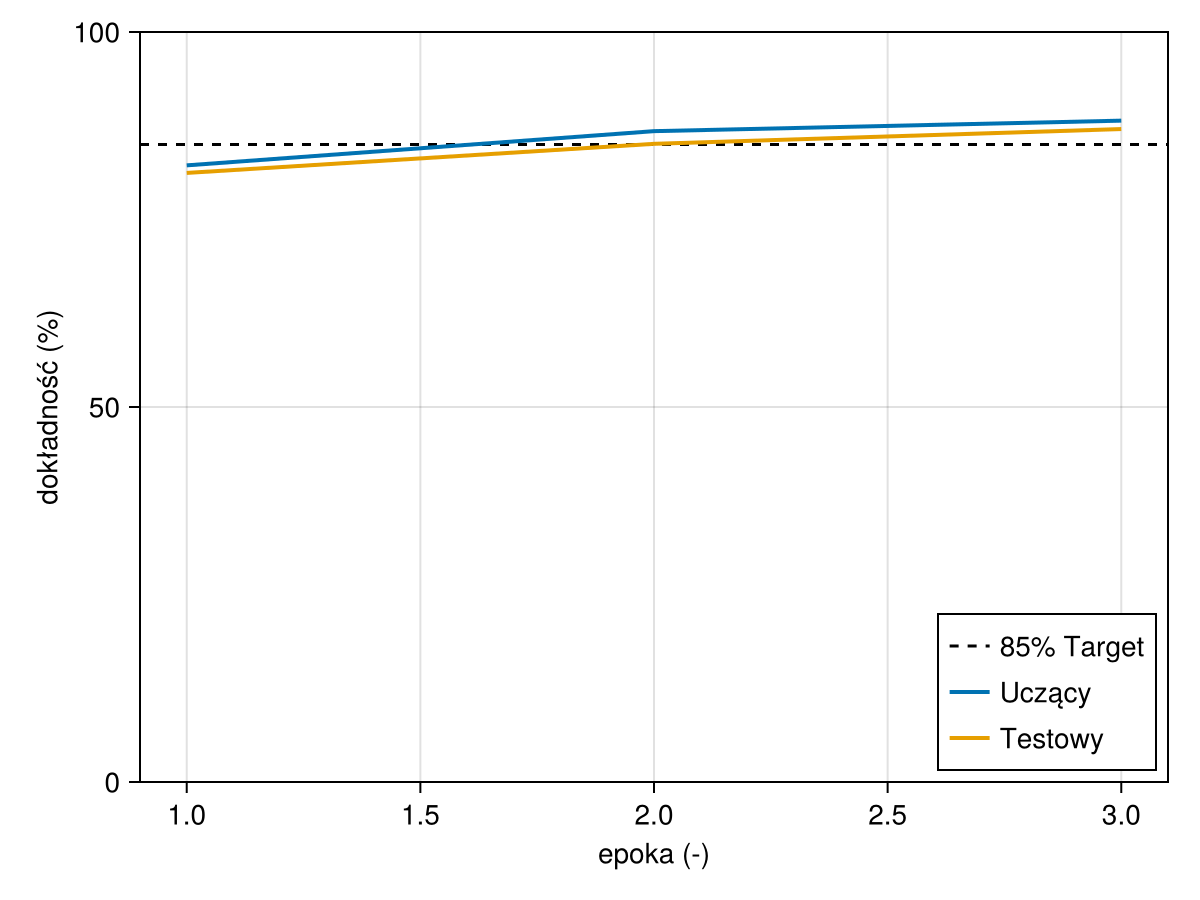

CairoMakie.Screen{IMAGE}


In [4]:
using MLDatasets, Flux
train_data = MLDatasets.FashionMNIST(split=:train)
test_data  = MLDatasets.FashionMNIST(split=:test)

function loader(data; batchsize::Int=1)
    x4dim = reshape(data.features, 28, 28, 1, :) # insert trivial channel dim
    yhot  = Flux.onehotbatch(data.targets, 0:9)  # make a 10×60000 OneHotMatrix
    Flux.DataLoader((x4dim, yhot); batchsize, shuffle=true)
end

function evaluate_accuracy(model_graph, data_loader, input_node, target_node, output_node)
    correct = 0
    total = 0
    
    # We use Flux's onecold to easily grab the index of the highest probability
    for (x, y) in data_loader
        # Skip incomplete batches at the tail end of the dataset
        if size(x, 4) != size(input_node.data, 4)
            continue
        end
        
        # Forward pass without backward or optimize
        forward!(model_graph, input_node => x, target_node => y)
        
        # onecold converts the one-hot encoded matrix back to class indices (0-9)
        pred = Flux.onecold(output_node.data, 0:9)
        truth = Flux.onecold(y, 0:9)
        
        correct += sum(pred .== truth)
        total += length(truth)
    end
    
    return correct / total
end

epochs = 3
η = 0.01
batch_size = 10

println("\n[x] Ładowanie danych...")
train_loader = loader(train_data; batchsize=batch_size)
test_loader  = loader(test_data; batchsize=batch_size)

println("[x] Budowanie architektury sieci neuronowej...")
net = chain((
  conv((3, 3), 1 => 6, pad=1, bias=false),
  maxpool((2, 2)),
  conv((3, 3), 6 => 16, pad=1, bias=false),
  maxpool((2, 2)),
  flatten(),
  dense(784 => 84, relu),
  dropout(0.4),
  dense(84 => 10)
))

input  = tensor(28, 28, 1, batch_size) 
target = tensor(10, batch_size)        
output = net(input) # Zwraca przedostatni GraphNode (przed lossem)
loss   = logitcrossentropy(output, target) # zwraca ostatni GraphNode (loss)
model  = graph(loss) # zwraca wektor GraphNode'ów w odpowiedniej kolejności

println("\n[x] Rozpoczynanie uczenia...")
accuracy = zeros(epochs, 2) # dla 3 epok: 3x2

for epoch in 1:epochs
    println("--- Epoka $epoch ---")
    
    @time begin
        for (x, y) in train_loader
            # Pomijanie niepełnych batchy (gdyby liczba danych nie była podzielna przez liczbę danych)
            if size(x, 4) != batch_size
                continue 
            end
            
            zerograd!(model) # zerowanie gradientów
            forward!(model, input => x, target => y) # przejście w przód
            backward!(model) # przejście w tył
            optimize!(model, η) # poprawienie wag (spadek gradientu)
        end
    end
    
    train_acc = evaluate_accuracy(model, train_loader, input, target, output)
    test_acc  = evaluate_accuracy(model, test_loader, input, target, output)
    
    train_acc_pct = round(train_acc * 100, digits=2)
    test_acc_pct  = round(test_acc * 100, digits=2)
    
    println("Dokładność na zbiorze uczącym: $train_acc_pct%")
    println("Dokładność na zbiorze testowym:  $test_acc_pct%\n")
    
    accuracy[epoch, 1] = train_acc_pct
    accuracy[epoch, 2] = test_acc_pct
end

println("[x] Generowanie wykresów...")
using CairoMakie

fig = Figure()
gca = Axis(fig[1,1], xlabel="epoka (-)", ylabel="dokładność (%)")
hlines!(85, linestyle=:dash, color=:black, label="85% Target")

lines!(gca, 1:epochs, accuracy[:,1], linewidth=2, label="Uczący")
lines!(gca, 1:epochs, accuracy[:,2], linewidth=2, label="Testowy")
ylims!(gca, (0, 100))
axislegend(gca, position = :rb)

display(fig)